In [34]:
!pip uninstall -y transformers datasets torchvision accelerate

Found existing installation: transformers 5.9.0
Uninstalling transformers-5.9.0:
  Successfully uninstalled transformers-5.9.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0


In [35]:
!pip install -q \
transformers==4.52.4 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.3 \
torchvision==0.24.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.2 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
!pip install transformers datasets accelerate -q

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

Data Loading

In [3]:
real_data = pd.read_csv('/content/drive/MyDrive/FakeNews/True.csv')
fake_data = pd.read_csv('/content/drive/MyDrive/FakeNews/Fake.csv')

real_data["label"] = 1
fake_data["label"] = 0

data = pd.concat([real_data, fake_data], ignore_index=True)

print("Total Samples:", len(data))
data.head()

Total Samples: 44898


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


Combining Text Columns

In [4]:
data["text"] = (data["title"].astype(str) + " " +
    data["text"].astype(str))

data = data[["text", "label"]]

# Remove duplicate articles
data = data.drop_duplicates(subset=["text"])
print("Total samples after removing duplicates:", len(data))
data.head()

Total samples after removing duplicates: 39105


,text,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


In [5]:
import re

def clean_text(text):
    text = re.sub(r"\(Reuters\)\s*-", "", text)
    return text

data["text"] = data["text"].apply(clean_text)

Checking Missing Values

In [6]:
print(data.isnull().sum())

text     0
label    0
dtype: int64


Train-Test Split

In [7]:
train_texts, test_texts, train_labels, test_labels = train_test_split(data["text"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"])

Converting to Hugging Face Dataset

In [8]:
train_df = pd.DataFrame({"text": train_texts, "label": train_labels})

test_df = pd.DataFrame({"text": test_texts, "label": test_labels})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [9]:
print(len(train_df))
print(len(test_df))

print(
    len(
        set(train_df["text"])
        &
        set(test_df["text"])
    )
)

31284
7821
0


Load DistilBERT Tokenizer

In [10]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [11]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

In [12]:
train_dataset = train_dataset.map(tokenize_function, batched=True)

test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/31284 [00:00<?, ? examples/s]

Map:   0%|          | 0/7821 [00:00<?, ? examples/s]

Setting PyTorch Format

In [13]:
train_dataset.set_format(type="torch",
    columns=["input_ids", "attention_mask", "label"])

test_dataset.set_format(type="torch",
    columns=["input_ids", "attention_mask", "label"])

Loading DistilBERT Model

In [14]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Metrics Function

In [15]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Training Arguments

In [16]:
training_args = TrainingArguments(output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=100,
    report_to="none")

Trainer

In [17]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
trainer = Trainer(model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics)

In [19]:
import torch
import torchvision
import transformers
import datasets

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

Torch: 2.9.1+cu128
Torchvision: 0.24.1+cu128
Transformers: 4.52.4
Datasets: 3.6.0


Training the Model

In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.025200,0.009292,0.997826,0.996472,0.999528,0.997998
2,0.002900,0.007689,0.999105,0.999764,0.998585,0.999174


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.025200,0.009292,0.997826,0.996472,0.999528,0.997998
2,0.002900,0.007689,0.999105,0.999764,0.998585,0.999174
3,0.000000,0.009178,0.998721,0.998585,0.999056,0.998821


TrainOutput(global_step=5868, training_loss=0.010356022234012635, metrics={'train_runtime': 2640.1985, 'train_samples_per_second': 35.547, 'train_steps_per_second': 2.223, 'total_flos': 6216165149331456.0, 'train_loss': 0.010356022234012635, 'epoch': 3.0})

Model Evaluation

In [22]:
results = trainer.evaluate()
results

{'eval_loss': 0.007688772864639759,
 'eval_accuracy': 0.9991049737885181,
 'eval_precision': 0.999763816721776,
 'eval_recall': 0.9985845718329794,
 'eval_f1': 0.9991738463354184,
 'eval_runtime': 67.9898,
 'eval_samples_per_second': 115.032,
 'eval_steps_per_second': 7.192,
 'epoch': 3.0}

Predictions

In [23]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [24]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3582
           1       1.00      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821



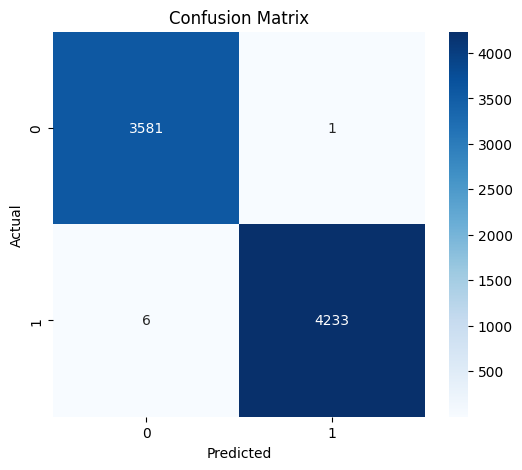

In [25]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9991
Precision : 0.9998
Recall    : 0.9986
F1 Score  : 0.9992


In [27]:
model.save_pretrained("/content/drive/MyDrive/FakeNews/distilbert_model")

tokenizer.save_pretrained("/content/drive/MyDrive/FakeNews/distilbert_model")

('/content/drive/MyDrive/FakeNews/distilbert_model/tokenizer_config.json',
 '/content/drive/MyDrive/FakeNews/distilbert_model/special_tokens_map.json',
 '/content/drive/MyDrive/FakeNews/distilbert_model/vocab.txt',
 '/content/drive/MyDrive/FakeNews/distilbert_model/added_tokens.json',
 '/content/drive/MyDrive/FakeNews/distilbert_model/tokenizer.json')

In [28]:
results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [acc, prec, rec, f1]
})

results_df.to_csv("/content/drive/MyDrive/FakeNews/results.csv", index=False)
print("Results Saved Successfully")

Results Saved Successfully


In [31]:
import torch
import numpy as np

# Convert logits to probabilities
probabilities = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

# Probability of class 1 (Real News)
y_scores = probabilities[:,1]

In [32]:
# Computing ROC-AUC Score
from sklearn.metrics import roc_curve, auc
y_scores = probabilities[:,1]
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9999891992267174


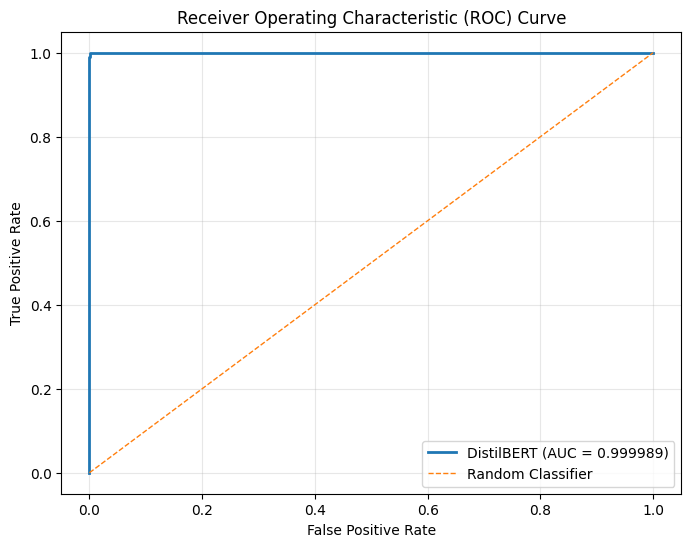

In [37]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2, label=f"DistilBERT (AUC = {roc_auc:.6f})")

plt.plot([0,1], [0,1], linestyle='--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig("roc_curve.png", dpi=300,bbox_inches='tight')
plt.show()

Sample Predictions

In [38]:
# Create prediction dataframe
prediction_df = pd.DataFrame({
    "Text": test_df["text"].values,
    "Actual": y_true,
    "Predicted": y_pred
})

# Convert labels to names
prediction_df["Actual"] = prediction_df["Actual"].map({
    0: "Fake News",
    1: "Real News"
})

prediction_df["Predicted"] = prediction_df["Predicted"].map({
    0: "Fake News",
    1: "Real News"
})

# Display 10 random samples
prediction_df.sample(10)

,Text,Actual,Predicted
1270,Obama sees no Middle East peace deal before hi...,Real News,Real News
5757,RICK SANTORUM INFURIATES LIBERALS After He Tel...,Fake News,Fake News
6482,Trump-Loving Oklahoma GOP Rep. Busted Calling...,Fake News,Fake News
1956,Kremlin says U.S. hacking allegations are 'rem...,Real News,Real News
6105,UPDATE: BUSTED By The Secret Service…CNN’s Apr...,Fake News,Fake News
2609,Austria's Kurz says will fight anti-Semitism a...,Real News,Real News
6988,Mexico enacts law to help find thousands missi...,Real News,Real News
1987,Leaked Audio: CEO Of CBS Gleefully Celebrates...,Fake News,Fake News
2751,Cambodia goes all-in on China in casino port c...,Real News,Real News
7783,German women ask Merkel for more support after...,Real News,Real News


In [39]:
for i in range(5):

    print("="*100)
    print("ARTICLE:")
    print(prediction_df.iloc[i]["Text"][:1000])   # First 1000 characters

    print("\nActual Label :", prediction_df.iloc[i]["Actual"])
    print("Predicted Label :", prediction_df.iloc[i]["Predicted"])
    print("="*100)
    print()

ARTICLE:
Episode #172 – SUNDAY WIRE: ‘Trumpe Le Monde’ with guests Trog Lodyte, Sarah Abed  Episode #172 of SUNDAY WIRE SHOW resumes this February 5, 2017 as host Patrick Henningsen brings you this week s 3 HOUR special LIVE broadcast on the Alternate Current Radio Network LISTEN LIVE ON THIS PAGE AT THE FOLLOWING SCHEDULED SHOW TIMES:LIVE BROADCAST TIMING: 5pm-8pm UK Time | 12pm-3pm ET (US) | 9am-12am PT (US)  This week s edition of THE SUNDAY WIRE is a very special LIVE broadcasting connecting North America and Europe this week, as host Patrick Henningsen covers the top stories in the US and internationally. In the first hour, we ll look at act one of Trump s foreign policy performance circus, as the NeoCons surround the new Don of Pennsylvania Ave, resuming Cheney & Bolton s Iran doctrine, as well as a continuation of Obama s dysfunctional Ukraine policy, and so much more. Later in hour one, we ll meet with our first guest, Syrian-American commentator Sarah Abed  to discuss the shif